# Exercise 6

In [249]:
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import math

### Part 1

In [250]:
seed = 30
rng = np.random.default_rng(seed=seed)

m = 10
A = 8

g = lambda i: A**(i)/(math.factorial(int(i)))
Is = np.array([0,1,2,3,4,5,6,7,8,9,10])

n = 10_000
X = np.zeros(n)

for j in range(n-1):
    new_i = X[j]
    while (new_i == X[j]):
        new_i = rng.choice(a=Is)
    
    alpha = np.min([1, g(new_i)/g(X[j])])

    chosen_i = rng.choice(a=[new_i, X[j]], p=[alpha, 1-alpha])

    X[j+1] = chosen_i

In [251]:
burn_in_length = int(n/10)
probs = np.array([np.sum(X[burn_in_length:] == Is[i])/(n-burn_in_length) for i in Is])
true_probs = np.array([g(i) for i in Is])/np.sum([g(i) for i in Is])

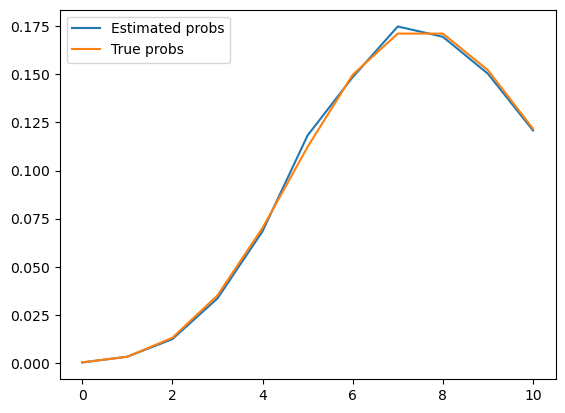

In [252]:
plt.plot(Is, probs, label='Estimated probs')
plt.plot(Is, true_probs, label='True probs')
plt.legend()
plt.show()

In [253]:
ss.chisquare(probs, true_probs, 0)[1]

1.0

### Part 2

In [254]:
seed = 30
rng = np.random.default_rng(seed=seed)

m = 10
A1 = 4
A2 = 4

g = lambda i,j: (A1**(i)*A2**(j))/(math.factorial(int(i))*math.factorial(int(j)))
Indices = np.array([0,1,2,3,4,5,6,7,8,9,10])

n = 1_00
X = np.zeros((2,n))

for k in range(n-1):
    new_indices = X[:,k]
    while (np.sum(new_indices == X[:,k]) == 2 or np.sum(new_indices) > m):
        new_indices = rng.choice(a=Indices, size=2)
    
    alpha = np.min([1, g(new_indices[0], new_indices[1])/g(X[0,k], X[1,k])])

    X[:,k+1] = rng.choice(a=[new_indices, X[:,k]], p=[alpha, 1-alpha])

burn_in_length = int(n/10)
counts = np.zeros(((m+1),(m+1)))
for k in range(burn_in_length,n):
    i = X[0,k]
    j = X[1,k]
    counts[int(i),int(j)] += 1
probs = counts/(n-burn_in_length)

true_probs = np.zeros(((m+1),(m+1)))
for i in range(m+1):
    for j in range(m+1):
        if (i+j <= 10):
            true_probs[i,j] = g(i,j)
true_probs = true_probs/np.sum(true_probs)

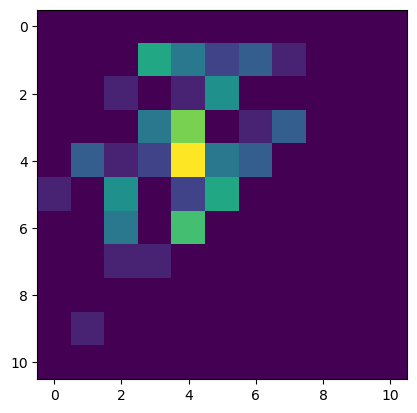

In [255]:
plt.imshow(probs)

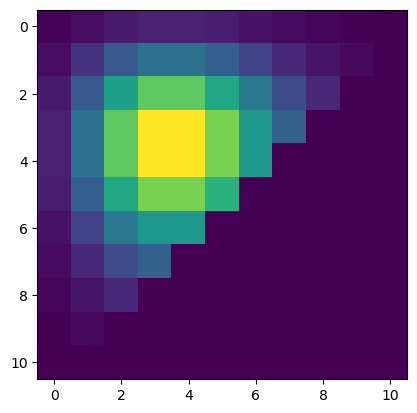

In [256]:
plt.imshow(true_probs)

In [266]:
temp = []
for i in range(m+1):
    for j in range(m+1):
        if (i+j >= 10):
            temp.append((i,j))
temp = np.array(temp)

In [258]:
ss.chisquare(probs.flatten()+1e-10, true_probs.flatten()+1e-10, ddof=55)[1]

1.0

In [259]:
total_occupation_probs = np.zeros(m+1)
true_total_occupation_probs = np.zeros(m+1)
for i in range(m+1):
    for j in range(m+1):
        if (i+j <= m):
            total_occupation_probs[i+j] += probs[i,j]
            true_total_occupation_probs[i+j]  += true_probs[i,j]

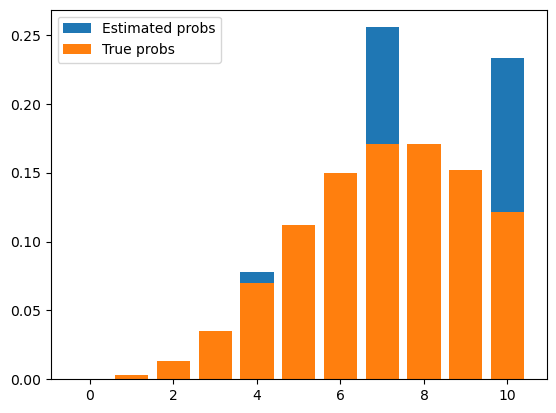

In [260]:
plt.bar(Is, total_occupation_probs, label='Estimated probs')
plt.bar(Is, true_total_occupation_probs, label='True probs')
plt.legend()
plt.show()